In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

In [453]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64 = error_type(None, np.float64)
f64_TO = error_type('T.O.', np.float64)

def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width']
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [f64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)

            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue

                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [454]:
def experiment_to_df_tsptw(fname, patterns=None, labels_list=None, types_list=None, scale_opt=None, opt_name='Opt'):
    exp = experiment_to_df(fname, patterns=patterns, labels_list=labels_list, types_list=types_list)
    
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

In [455]:
non_triangular = ['OhlmannThomas/n150w120.003.txt','OhlmannThomas/n150w120.002.txt','OhlmannThomas/n150w120.001.txt','OhlmannThomas/n150w120.005.txt','OhlmannThomas/n150w120.004.txt','OhlmannThomas/n150w140.005.txt','OhlmannThomas/n150w140.004.txt','OhlmannThomas/n150w140.003.txt','OhlmannThomas/n150w140.002.txt','OhlmannThomas/n150w140.001.txt','OhlmannThomas/n200w140.005.txt','OhlmannThomas/n200w140.004.txt','OhlmannThomas/n200w140.001.txt','OhlmannThomas/n200w140.003.txt','OhlmannThomas/n200w140.002.txt','OhlmannThomas/n200w120.001.txt','OhlmannThomas/n150w160.001.txt','OhlmannThomas/n150w160.003.txt','OhlmannThomas/n200w120.003.txt','OhlmannThomas/n200w120.002.txt','OhlmannThomas/n150w160.002.txt','OhlmannThomas/n150w160.005.txt','OhlmannThomas/n200w120.005.txt','OhlmannThomas/n200w120.004.txt','OhlmannThomas/n150w160.004.txt','toy/toy2.tw','Dumas/n60w100.005.txt','Dumas/n80w60.001.txt','Dumas/n150w40.004.txt','Dumas/n60w20.004.txt','Dumas/n100w40.001.txt','Dumas/n150w40.005.txt','Dumas/n60w20.005.txt','Dumas/n60w100.004.txt','Dumas/n80w60.002.txt','Dumas/n60w80.004.txt','Dumas/n100w40.002.txt','Dumas/n40w60.004.txt','Dumas/n40w60.005.txt','Dumas/n100w40.003.txt','Dumas/n60w80.005.txt','Dumas/n80w60.003.txt','Dumas/n60w100.003.txt','Dumas/n150w40.002.txt','Dumas/n60w20.002.txt','Dumas/n60w80.001.txt','Dumas/n40w60.001.txt','Dumas/n150w40.003.txt','Dumas/n60w20.003.txt','Dumas/n60w100.002.txt','Dumas/n80w60.004.txt','Dumas/n60w20.001.txt','Dumas/n150w40.001.txt','Dumas/n100w40.004.txt','Dumas/n60w80.002.txt','Dumas/n40w60.002.txt','Dumas/n40w60.003.txt','Dumas/n60w80.003.txt','Dumas/n100w40.005.txt','Dumas/n80w60.005.txt','Dumas/n60w100.001.txt','Dumas/n150w20.002.txt','Dumas/n60w40.002.txt','Dumas/n150w20.003.txt','Dumas/n60w40.003.txt','Dumas/n60w40.001.txt','Dumas/n150w20.001.txt','Dumas/n20w60.005.txt','Dumas/n100w20.004.txt','Dumas/n100w20.005.txt','Dumas/n20w60.004.txt','Dumas/n150w20.004.txt','Dumas/n60w40.004.txt','Dumas/n100w20.001.txt','Dumas/n20w60.001.txt','Dumas/n150w20.005.txt','Dumas/n60w40.005.txt','Dumas/n100w20.002.txt','Dumas/n100w20.003.txt','Dumas/n20w60.002.txt','Dumas/n150w60.001.txt','Dumas/n80w40.004.txt','Dumas/n100w60.004.txt','Dumas/n40w40.002.txt','Dumas/n40w40.003.txt','Dumas/n100w60.005.txt','Dumas/n80w40.005.txt','Dumas/n20w20.004.txt','Dumas/n150w60.002.txt','Dumas/n200w20.005.txt','Dumas/n40w40.001.txt','Dumas/n20w80.004.txt','Dumas/n200w20.004.txt','Dumas/n150w60.003.txt','Dumas/n20w20.003.txt','Dumas/n80w40.002.txt','Dumas/n100w60.002.txt','Dumas/n40w40.004.txt','Dumas/n40w40.005.txt','Dumas/n100w60.003.txt','Dumas/n200w20.001.txt','Dumas/n80w40.003.txt','Dumas/n20w20.002.txt','Dumas/n150w60.004.txt','Dumas/n80w40.001.txt','Dumas/n200w20.003.txt','Dumas/n100w60.001.txt','Dumas/n20w80.002.txt','Dumas/n200w20.002.txt','Dumas/n150w60.005.txt','Dumas/n20w20.001.txt','Dumas/n80w20.002.txt','Dumas/n20w40.003.txt','Dumas/n20w100.004.txt','Dumas/n40w20.004.txt','Dumas/n40w100.003.txt','Dumas/n80w80.001.txt','Dumas/n200w40.001.txt','Dumas/n40w100.002.txt','Dumas/n40w20.005.txt','Dumas/n20w100.005.txt','Dumas/n80w20.003.txt','Dumas/n60w60.004.txt','Dumas/n80w20.001.txt','Dumas/n40w80.004.txt','Dumas/n80w80.002.txt','Dumas/n200w40.003.txt','Dumas/n200w40.002.txt','Dumas/n80w80.003.txt','Dumas/n40w100.001.txt','Dumas/n20w40.001.txt','Dumas/n40w80.005.txt','Dumas/n60w60.005.txt','Dumas/n60w60.001.txt','Dumas/n80w20.004.txt','Dumas/n40w80.001.txt','Dumas/n40w100.005.txt','Dumas/n40w20.002.txt','Dumas/n40w20.003.txt','Dumas/n40w100.004.txt','Dumas/n20w100.003.txt','Dumas/n80w20.005.txt','Dumas/n60w60.002.txt','Dumas/n40w80.002.txt','Dumas/n40w20.001.txt','Dumas/n80w80.004.txt','Dumas/n200w40.005.txt','Dumas/n200w40.004.txt','Dumas/n80w80.005.txt','Dumas/n40w80.003.txt','Dumas/n60w60.003.txt','GendreauDumasExtended/n20w200.005.txt','GendreauDumasExtended/n80w120.005.txt','GendreauDumasExtended/n40w200.002.txt','GendreauDumasExtended/n40w200.003.txt','GendreauDumasExtended/n80w120.004.txt','GendreauDumasExtended/n40w140.001.txt','GendreauDumasExtended/n20w200.004.txt','GendreauDumasExtended/n80w180.005.txt','GendreauDumasExtended/n100w160.005.txt','GendreauDumasExtended/n40w140.003.txt','GendreauDumasExtended/n40w200.001.txt','GendreauDumasExtended/n40w140.002.txt','GendreauDumasExtended/n100w160.004.txt','GendreauDumasExtended/n80w180.004.txt','GendreauDumasExtended/n20w140.001.txt','GendreauDumasExtended/n20w200.003.txt','GendreauDumasExtended/n80w120.003.txt','GendreauDumasExtended/n40w200.004.txt','GendreauDumasExtended/n40w200.005.txt','GendreauDumasExtended/n80w120.002.txt','GendreauDumasExtended/n100w160.001.txt','GendreauDumasExtended/n80w180.001.txt','GendreauDumasExtended/n80w180.003.txt','GendreauDumasExtended/n100w160.003.txt','GendreauDumasExtended/n40w140.005.txt','GendreauDumasExtended/n80w120.001.txt','GendreauDumasExtended/n40w140.004.txt','GendreauDumasExtended/n100w160.002.txt','GendreauDumasExtended/n80w180.002.txt','GendreauDumasExtended/n20w140.003.txt','GendreauDumasExtended/n60w160.003.txt','GendreauDumasExtended/n100w80.004.txt','GendreauDumasExtended/n20w120.001.txt','GendreauDumasExtended/n40w180.005.txt','GendreauDumasExtended/n80w140.003.txt','GendreauDumasExtended/n20w180.002.txt','GendreauDumasExtended/n80w200.001.txt','GendreauDumasExtended/n100w100.001.txt','GendreauDumasExtended/n80w140.002.txt','GendreauDumasExtended/n40w180.004.txt','GendreauDumasExtended/n100w80.005.txt','GendreauDumasExtended/n60w160.002.txt','GendreauDumasExtended/n20w120.002.txt','GendreauDumasExtended/n40w120.005.txt','GendreauDumasExtended/n80w200.002.txt','GendreauDumasExtended/n100w100.003.txt','GendreauDumasExtended/n100w100.002.txt','GendreauDumasExtended/n80w200.003.txt','GendreauDumasExtended/n40w120.004.txt','GendreauDumasExtended/n80w140.001.txt','GendreauDumasExtended/n20w120.003.txt','GendreauDumasExtended/n60w160.001.txt','GendreauDumasExtended/n60w160.005.txt','GendreauDumasExtended/n100w80.002.txt','GendreauDumasExtended/n40w180.003.txt','GendreauDumasExtended/n80w140.005.txt','GendreauDumasExtended/n20w180.004.txt','GendreauDumasExtended/n40w120.001.txt','GendreauDumasExtended/n80w140.004.txt','GendreauDumasExtended/n40w180.002.txt','GendreauDumasExtended/n100w80.003.txt','GendreauDumasExtended/n60w160.004.txt','GendreauDumasExtended/n100w80.001.txt','GendreauDumasExtended/n20w120.004.txt','GendreauDumasExtended/n40w120.003.txt','GendreauDumasExtended/n80w200.004.txt','GendreauDumasExtended/n100w100.005.txt','GendreauDumasExtended/n100w100.004.txt','GendreauDumasExtended/n80w200.005.txt','GendreauDumasExtended/n40w120.002.txt','GendreauDumasExtended/n40w180.001.txt','GendreauDumasExtended/n20w160.002.txt','GendreauDumasExtended/n60w180.003.txt','GendreauDumasExtended/n100w140.003.txt','GendreauDumasExtended/n40w160.005.txt','GendreauDumasExtended/n40w160.004.txt','GendreauDumasExtended/n80w100.001.txt','GendreauDumasExtended/n100w140.002.txt','GendreauDumasExtended/n60w180.002.txt','GendreauDumasExtended/n60w120.001.txt','GendreauDumasExtended/n20w160.001.txt','GendreauDumasExtended/n60w120.003.txt','GendreauDumasExtended/n80w100.003.txt','GendreauDumasExtended/n80w100.002.txt','GendreauDumasExtended/n60w180.001.txt','GendreauDumasExtended/n100w140.001.txt','GendreauDumasExtended/n60w120.002.txt','GendreauDumasExtended/n20w160.004.txt','GendreauDumasExtended/n100w140.005.txt','GendreauDumasExtended/n60w180.005.txt','GendreauDumasExtended/n40w160.003.txt','GendreauDumasExtended/n40w160.002.txt','GendreauDumasExtended/n60w180.004.txt','GendreauDumasExtended/n100w140.004.txt','GendreauDumasExtended/n20w160.005.txt','GendreauDumasExtended/n60w120.005.txt','GendreauDumasExtended/n80w100.005.txt','GendreauDumasExtended/n40w160.001.txt','GendreauDumasExtended/n80w100.004.txt','GendreauDumasExtended/n60w120.004.txt','GendreauDumasExtended/n60w200.004.txt','GendreauDumasExtended/n100w120.005.txt','GendreauDumasExtended/n100w120.004.txt','GendreauDumasExtended/n60w200.005.txt','GendreauDumasExtended/n60w140.005.txt','GendreauDumasExtended/n80w160.005.txt','GendreauDumasExtended/n80w160.004.txt','GendreauDumasExtended/n60w140.004.txt','GendreauDumasExtended/n60w200.002.txt','GendreauDumasExtended/n100w120.003.txt','GendreauDumasExtended/n100w120.002.txt','GendreauDumasExtended/n80w160.001.txt','GendreauDumasExtended/n60w140.001.txt','GendreauDumasExtended/n60w200.003.txt','GendreauDumasExtended/n60w200.001.txt','GendreauDumasExtended/n60w140.003.txt','GendreauDumasExtended/n80w160.003.txt','GendreauDumasExtended/n100w120.001.txt','GendreauDumasExtended/n80w160.002.txt','GendreauDumasExtended/n60w140.002.txt','Langevin/N40ft207.dat','Langevin/N20ft406.dat','Langevin/N40ft401.dat','Langevin/N20ft407.dat','Langevin/N40ft206.dat','Langevin/N40ft204.dat','Langevin/N40ft210.dat','Langevin/N20ft405.dat','Langevin/N40ft402.dat','Langevin/N40ft403.dat','Langevin/N20ft404.dat','Langevin/N20ft410.dat','Langevin/N40ft205.dat','Langevin/N40ft201.dat','Langevin/N40ft407.dat','Langevin/N40ft406.dat','Langevin/N20ft401.dat','Langevin/N60ft309.dat','Langevin/N40ft202.dat','Langevin/N20ft403.dat','Langevin/N40ft404.dat','Langevin/N40ft410.dat','Langevin/N40ft405.dat','Langevin/N20ft402.dat','Langevin/N40ft203.dat','Langevin/N60ft308.dat','Langevin/N60ft409.dat','Langevin/N20ft303.dat','Langevin/N20ft302.dat','Langevin/N60ft408.dat','Langevin/N20ft301.dat','Langevin/N20ft305.dat','Langevin/N60ft209.dat','Langevin/N60ft208.dat','Langevin/N20ft304.dat','Langevin/N20ft310.dat','Langevin/N20ft306.dat','Langevin/N20ft307.dat','Langevin/N60ft206.dat','Langevin/N60ft207.dat','Langevin/N60ft401.dat','Langevin/N60ft403.dat','Langevin/N20ft309.dat','Langevin/N60ft205.dat','Langevin/N60ft204.dat','Langevin/N60ft210.dat','Langevin/N20ft308.dat','Langevin/N60ft402.dat','Langevin/N60ft406.dat','Langevin/N60ft201.dat','Langevin/N60ft407.dat','Langevin/N60ft405.dat','Langevin/N60ft203.dat','Langevin/N60ft202.dat','Langevin/N60ft404.dat','Langevin/N60ft410.dat','Langevin/N60ft305.dat','Langevin/N40ft408.dat','Langevin/N40ft409.dat','Langevin/N60ft304.dat','Langevin/N60ft310.dat','Langevin/N60ft306.dat','Langevin/N60ft307.dat','Langevin/N60ft303.dat','Langevin/N40ft208.dat','Langevin/N20ft409.dat','Langevin/N20ft408.dat','Langevin/N40ft209.dat','Langevin/N60ft302.dat','Langevin/N60ft301.dat']
triangular = ['toy/toy1.tw','Dumas/n20w60.003.txt','Dumas/n20w20.005.txt','Dumas/n20w80.005.txt','Dumas/n20w80.001.txt','Dumas/n20w80.003.txt','Dumas/n20w40.002.txt','Dumas/n20w40.005.txt','Dumas/n20w100.002.txt','Dumas/n20w40.004.txt','Dumas/n20w100.001.txt','SolomonPotvinBengio/rc_206.4.txt','SolomonPotvinBengio/rc_202.1.txt','SolomonPotvinBengio/rc_202.3.txt','SolomonPotvinBengio/rc_202.2.txt','SolomonPotvinBengio/rc_206.2.txt','SolomonPotvinBengio/rc_204.1.txt','SolomonPotvinBengio/rc_206.3.txt','SolomonPotvinBengio/rc_206.1.txt','SolomonPotvinBengio/rc_204.3.txt','SolomonPotvinBengio/rc_202.4.txt','SolomonPotvinBengio/rc_204.2.txt','SolomonPotvinBengio/rc_201.1.txt','SolomonPotvinBengio/rc_203.3.txt','SolomonPotvinBengio/rc_205.4.txt','SolomonPotvinBengio/rc_203.2.txt','SolomonPotvinBengio/rc_201.2.txt','SolomonPotvinBengio/rc_207.4.txt','SolomonPotvinBengio/rc_203.1.txt','SolomonPotvinBengio/rc_201.3.txt','SolomonPotvinBengio/rc_205.3.txt','SolomonPotvinBengio/rc_207.1.txt','SolomonPotvinBengio/rc_205.2.txt','SolomonPotvinBengio/rc_203.4.txt','SolomonPotvinBengio/rc_201.4.txt','SolomonPotvinBengio/rc_207.2.txt','SolomonPotvinBengio/rc_207.3.txt','SolomonPotvinBengio/rc_205.1.txt','SolomonPotvinBengio/rc_208.2.txt','SolomonPotvinBengio/rc_208.3.txt','SolomonPotvinBengio/rc_208.1.txt','GendreauDumasExtended/n20w140.004.txt','GendreauDumasExtended/n20w140.005.txt','GendreauDumasExtended/n20w200.002.txt','GendreauDumasExtended/n20w140.002.txt','GendreauDumasExtended/n20w200.001.txt','GendreauDumasExtended/n20w180.003.txt','GendreauDumasExtended/n20w180.001.txt','GendreauDumasExtended/n20w180.005.txt','GendreauDumasExtended/n20w120.005.txt','GendreauDumasExtended/n20w160.003.txt','SolomonPesant/rc201.1','SolomonPesant/rc203.2','SolomonPesant/rc205.0','SolomonPesant/rc201.0','SolomonPesant/rc207.2','SolomonPesant/rc205.1','SolomonPesant/rc206.0','SolomonPesant/rc202.1','SolomonPesant/rc208.1','SolomonPesant/rc204.2','SolomonPesant/rc206.1','SolomonPesant/rc208.0','SolomonPesant/rc202.0','SolomonPesant/rc205.3','SolomonPesant/rc207.0','SolomonPesant/rc201.2','SolomonPesant/rc203.1','SolomonPesant/rc207.1','SolomonPesant/rc205.2','SolomonPesant/rc203.0','SolomonPesant/rc201.3','SolomonPesant/rc202.2','SolomonPesant/rc208.2','SolomonPesant/rc204.0','SolomonPesant/rc202.3','SolomonPesant/rc204.1','SolomonPesant/rc206.2','AFG/rbg040a.tw','AFG/rbg041a.tw','AFG/rbg055a.tw','AFG/rbg021.8.tw','AFG/rbg042a.tw','AFG/rbg021.9.tw','AFG/rbg035a.2.tw','AFG/rbg125a.tw','AFG/rbg092a.tw','AFG/rbg086a.tw','AFG/rbg050a.tw','AFG/rbg193.tw','AFG/rbg021.6.tw','AFG/rbg019d.tw','AFG/rbg017.2.tw','AFG/rbg021.2.tw','AFG/rbg020a.tw','AFG/rbg034a.tw','AFG/rbg035a.tw','AFG/rbg233.tw','AFG/rbg021.3.tw','AFG/rbg019a.tw','AFG/rbg031a.tw','AFG/rbg016b.tw','AFG/rbg132.2.tw','AFG/rbg021.tw','AFG/rbg021.7.tw','AFG/rbg152.3.tw','AFG/rbg027a.tw','AFG/rbg033a.tw','AFG/rbg152.tw','AFG/rbg016a.tw','AFG/rbg019b.tw','AFG/rbg017a.tw','AFG/rbg193.2.tw','AFG/rbg201a.tw','AFG/rbg021.4.tw','AFG/rbg021.5.tw','AFG/rbg132.tw','AFG/rbg017.tw','AFG/rbg038a.tw','AFG/rbg010a.tw','AFG/rbg019c.tw','AFG/rbg172a.tw','AFG/rbg049a.tw','AFG/rbg048a.tw','AFG/rbg050b.tw','AFG/rbg067a.tw','AFG/rbg050c.tw','AFG/rbg233.2.tw']

In [472]:
exp1 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_XFLD_ddolocal_final', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')
exp2 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_XFLD_coddlocal_final', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
exp3 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_XFLD_codd_final', scale_opt=10000.0); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')
exp4 = experiment_to_df_tsptw('tsptw_TO_100s/tsptw_didp_final', scale_opt=10000.0, opt_name='Opt_didp', patterns=[r'(\S+)', f'T.O.|t: ({flt}), cost: (\\d+)'], labels_list=[['Bench'],['Proof Time_didp', 'Opt_didp']], types_list=[[str],[f64_TO, i32]]); exp4['Bench'] = exp4['Bench'].str.split('/').str[-2:].str.join('/')

# exp1 = experiment_to_df_tsptw('tsptw_TO_1000s_realfixlocal_tri/tsptw_XFL_1000', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')
# exp2 = experiment_to_df_tsptw('tsptw_TO_1000s_realfixlocal_tri/tsptw_RFL_1000', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
# exp3 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_didp_1000', scale_opt=10000.0, opt_name='Opt_didp', patterns=[r'(\S+)', f't: ({flt}), cost: (\\d+)'], labels_list=[['Bench'],['Proof Time_didp', 'Opt_didp']], types_list=[[str],[np.float64, np.int32]]); exp3['Bench'] = exp3['Bench'].str.split('/').str[-2:].str.join('/')

# exp4 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_ddo_1000', labels_list=[['Bench', None],['Opt_ddo', None, None, None, None, None, 'Proof Time_ddo', None, None]]); exp4['Bench'] = exp4['Bench'].str.split('/').str[-2:].str.join('/')

# exp1 = exp1[exp1['Opt'].notna()]
# exp2 = exp2[exp2['Opt'].notna()]

L = 0; R = 1
suffixes = ('_codd_dl', '_codd_cd', '_codd', 'didp')
# suffixes = ('_XF', '_RF', '_x', '_y')
merge = pd.merge(exp1, exp2, on=['Bench', 'Width'], how='inner', suffixes=suffixes[:2]).merge(exp3, on=['Bench'], how='inner')#.merge(exp4, on=['Bench'], how='inner')
final = merge #merge[merge["Bench"].isin(triangular)]
#final[~final.notna()] = 'T.O.'
final

FileNotFoundError: [Errno 2] No such file or directory: './tsptw_TO_100s/tsptw_XFLD_codd_final.dat'

In [457]:
def average_speedup(L, R, w, exclude_below_L=None):
    global final
    L_times = final[f'Proof Time{suffixes[L]}']
    R_times = final[f'Proof Time{suffixes[R]}']
    L_times = L_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.') & (final['Width']==w)]
    R_times = R_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.') & (final['Width']==w)]

    if exclude_below_L is not None:
        R_times = R_times[L_times >= exclude_below_L]        
        L_times = L_times[L_times >= exclude_below_L]

    speedup = R_times / L_times
    # print(speedup)
    speedup = speedup.astype(float).replace(np.inf, np.nan).dropna()

    avg = np.average(speedup)
    if avg >= 1:
        print(f'{suffixes[L]} is {avg:.2f}x faster than {suffixes[R]}  ')
    else:
        print(f'{suffixes[L]} is {avg:.2f}x faster than {suffixes[R]} ({1/avg:.2f}x slower)')
    #print(f'                = {avg:.2f}')
    # else:
    #     print(f'average slowdown = {1/avg}')
    #     print(f'                 = {1/avg:.2f}')

In [458]:
for w in set(final['Width']):
    print(f'w={w}')
    average_speedup(0,1,w)
    average_speedup(0,2,w)
    print(f'ignoring {suffixes[L]} < 1s')
    average_speedup(0,1,w,exclude_below_L=1)
    average_speedup(0,2,w,exclude_below_L=1)
    print()

w=8
_XF is 0.73x faster than _RF (1.38x slower)
_XF is 0.37x faster than _didp (2.67x slower)
ignoring _XF < 1s
_XF is 0.87x faster than _RF (1.16x slower)
_XF is 0.01x faster than _didp (67.56x slower)



In [459]:
for suffix in suffixes:
    print(f'# where {suffix} solved within timeout: ')
    print('\t'.join(f'w={w}' for w in set(final['Width'])))
    for w in set(final['Width']):
        print(f'{len(final[ (final[f"Proof Time{suffix}"]!="T.O.") & (final["Width"]==w) ])}', end='\t')
    print()

# where _XF solved within timeout: 
w=8
84	
# where _RF solved within timeout: 
w=8
87	
# where _didp solved within timeout: 
w=8
88	


In [460]:
def TO_solves(L,R):
    X_TO = final[(final[f'Proof Time{suffixes[L]}']=='T.O.') & (final[f'Proof Time{suffixes[R]}']!='T.O.') & (final[f'Proof Time{suffixes[R]}'].notna()) & (final[f'Proof Time{suffixes[L]}'].notna())]
    R_TO = final[(final[f'Proof Time{suffixes[L]}']!='T.O.') & (final[f'Proof Time{suffixes[R]}']=='T.O.') & (final[f'Proof Time{suffixes[R]}'].notna()) & (final[f'Proof Time{suffixes[L]}'].notna())]
    print(f'# where {suffixes[L]} TOs, {suffixes[R]} solves: {len(X_TO)}')
    print(f'# where {suffixes[R]} TOs, {suffixes[L]} solves: {len(R_TO)}\n')
TO_solves(0,1)
TO_solves(1,2)
TO_solves(0,2)
# TO_solves(1,3)

# where _XF TOs, _RF solves: 3
# where _RF TOs, _XF solves: 0

# where _RF TOs, _didp solves: 1
# where _didp TOs, _RF solves: 0

# where _XF TOs, _didp solves: 4
# where _didp TOs, _XF solves: 0



In [461]:
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_RF disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp


In [462]:
R=2
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_didp disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp


In [463]:
# R=3
# print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
# final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

In [464]:
# L=2
# R=3
# print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
# final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

In [465]:
plt.rcParams['figure.figsize'] = [14,4]
def cum_plot(df, column, log=False, ep=1e-6, sort_by=0, title='', find_peaks=None):
    s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    if sort_by is not None: df = df.sort_values(by=f'{column}{suffixes[sort_by]}')
    #print(df['Bench'])

    _,[ax1,ax2] = plt.subplots(1,2)

    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        Ys += ep
        ax1.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax1.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    ax1.set_xlabel('# of Experiments')
    ax1.set_ylabel(f'Cumulative {column} (log)' if log else f'Cumulative {column}')
    ax1.set_title(title)
    ax1.legend()
    
    Ys = np.array([df[f'{column}{suffix}'] for suffix in s])
    if log:
        Ys += ep
        ax2.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax2.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])

    if find_peaks is not None:
        for i in find_peaks:
            Y = Ys[i]
            dY = np.diff(Y)
            peaks = np.where((dY[:-1] > 0) & (dY[1:] < 0) & (np.abs(Y[1:-1]-Ys[sort_by][1:-1]) > 1))[0] + 1 
            ax2.scatter(X[peaks],Y[peaks],marker='x')
            print(df.iloc[peaks][['Bench', f'Proof Time{suffixes[i]}']])

    ax2.set_xlabel('# of Experiments')
    ax2.set_ylabel(f'{column} (log)' if log else f'{column}')
    ax2.set_title(title)
    ax2.legend()
    plt.show()

                    Bench Proof Time_XF
73  Langevin/N60ft408.dat         1.435
78  SolomonPesant/rc201.1         1.941
74  Langevin/N60ft409.dat         3.777
69  Langevin/N60ft404.dat         4.129
75  Langevin/N60ft410.dat         7.639
                               Bench Proof Time_RF
73             Langevin/N60ft408.dat         2.252
74             Langevin/N60ft409.dat         3.234
87  SolomonPotvinBengio/rc_201.3.txt         2.371
75             Langevin/N60ft410.dat        18.016


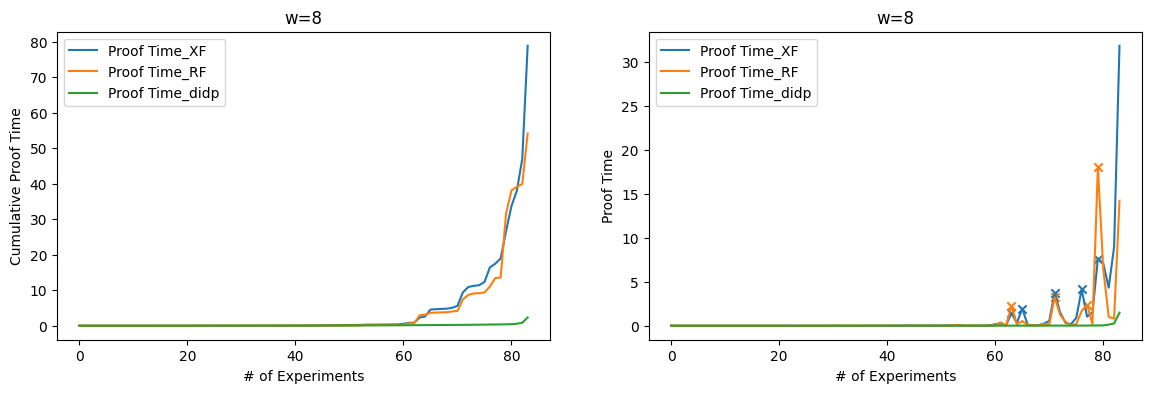

In [466]:
for w in set(final['Width']):
    cum_plot(final[final['Width']==w], 'Proof Time', sort_by=2, find_peaks=[0,1], title=f"w={w}")

In [467]:
final[final['Bench']=='AFG/rbg021.2.tw']

,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp


In [468]:
pd.DataFrame({'Bench':['AFG/rbg021.2.tw']*4, 'Width':[8,16,32,64], 'Opt_XF':[4528.]*4, 'nodes1_XF':[12716,9631,6219,8608], 'nodes2_XF':[12748,9648,6220,8610], 'P_XF':[8133,5798,3373,4124], 'D_XF':[24568,18251,11319,16238], 'Opt Time_XF':[1.39999999,1.092,0.132,0.213], 'Proof Time_XF':[1.707, 1.294,0.87,1.449]})

,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF
0,AFG/rbg021.2.tw,8,4528.0,12716,12748,8133,24568,1.400,1.707
1,AFG/rbg021.2.tw,16,4528.0,9631,9648,5798,18251,1.092,1.294
2,AFG/rbg021.2.tw,32,4528.0,6219,6220,3373,11319,0.132,0.870
3,AFG/rbg021.2.tw,64,4528.0,8608,8610,4124,16238,0.213,1.449


                    Bench Proof Time_XF
73  Langevin/N60ft408.dat         1.435
78  SolomonPesant/rc201.1         1.941
74  Langevin/N60ft409.dat         3.777
69  Langevin/N60ft404.dat         4.129
75  Langevin/N60ft410.dat         7.639
                               Bench Proof Time_RF
73             Langevin/N60ft408.dat         2.252
74             Langevin/N60ft409.dat         3.234
87  SolomonPotvinBengio/rc_201.3.txt         2.371
75             Langevin/N60ft410.dat        18.016


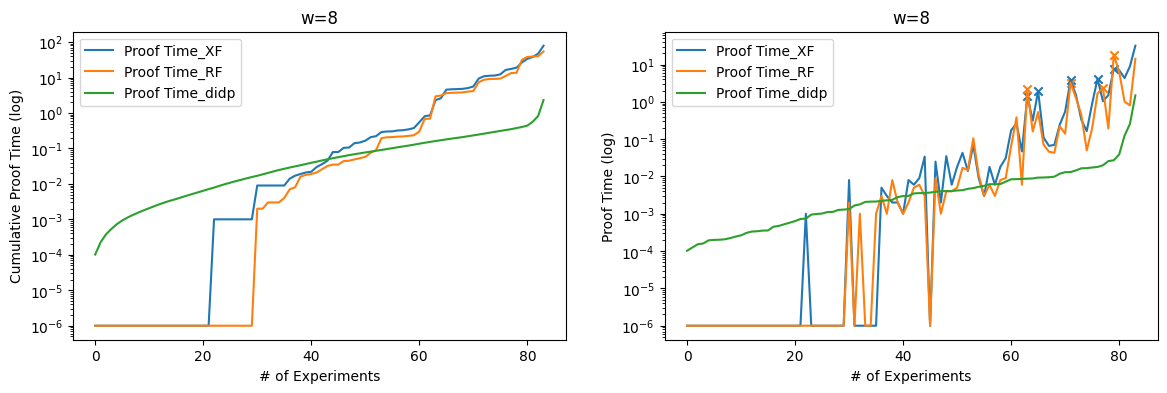

In [469]:
for w in set(final['Width']):
    cum_plot(final[final['Width']==w], 'Proof Time', sort_by=2, find_peaks=[0,1], title=f"w={w}", log=True)

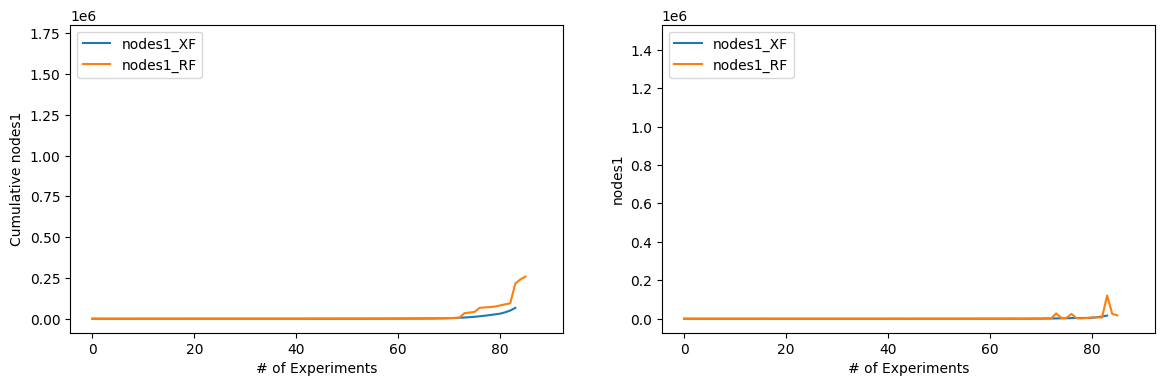

In [470]:
cum_plot(final, 'nodes1')

TypeError: unsupported operand type(s) for +: 'NoneType' and 'float'

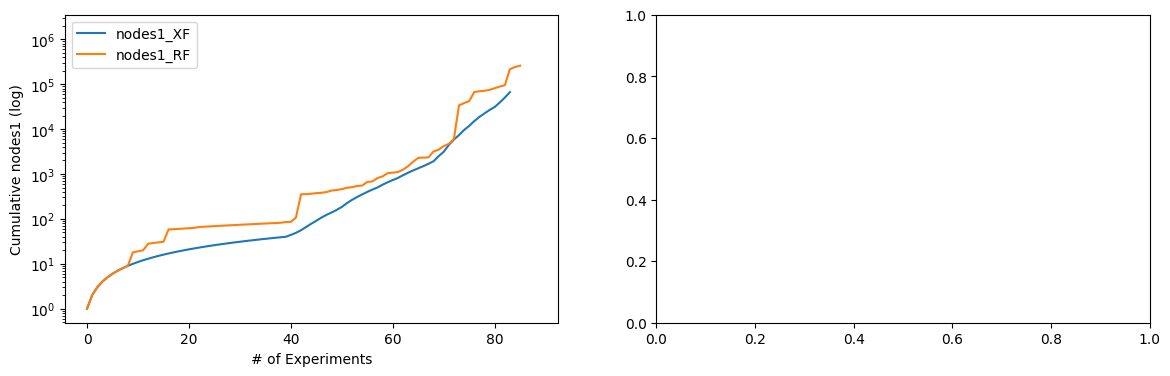

In [471]:
cum_plot(final, 'nodes1', log=True)

In [ ]:
def valid_benches(exp, prefix='../data/tsptw'):
    return ' '.join([f'{prefix}/{x}' for x in exp1['Bench'].drop_duplicates()])

In [ ]:
exp = experiment_to_df_tsptw('tsptw_TO_1000s_fixlocal/tsptw_RFL_1000', scale_opt=10000.0); exp['Bench'] = exp['Bench'].str.split('/').str[-2:].str.join('/')
valid_benches(exp, prefix='./resources/tsptw')

'./resources/tsptw/AFG/rbg010a.tw ./resources/tsptw/AFG/rbg016a.tw ./resources/tsptw/AFG/rbg016b.tw ./resources/tsptw/AFG/rbg017.2.tw'

In [ ]:
valid_benches(exp1)

'../data/tsptw/AFG/rbg010a.tw ../data/tsptw/AFG/rbg016a.tw ../data/tsptw/AFG/rbg016b.tw ../data/tsptw/AFG/rbg017.2.tw'

In [ ]:
final.head(20)

,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp
0,AFG/rbg010a.tw,8,671.0,155,155,1,4,0.001,0.003,671.0,27,27,0,0,0.0,0.002,0.001335,671.0
1,AFG/rbg016a.tw,8,938.0,6,6,0,0,0.001,0.001,938.0,12,12,0,0,0.0,0.002,0.003001,938.0
2,AFG/rbg016b.tw,8,1304.0,1470,1474,177,602,0.094,0.168,1304.0,2044,2044,0,0,0.102,0.192,0.025762,1304.0
3,AFG/rbg017.2.tw,8,853.0,31892,47676,4315,28130,16.783,16.786,852.0,25455,25455,0,0,2.25,2.446,0.454231,852.0


In [ ]:
numeric = final[final['Proof Time_RF'] != 'T.O.']
#numeric[numeric['Proof Time_XF'] >= 100]
numeric.sort_values(by='Proof Time_RF', ascending=False).head(4)

,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp
3,AFG/rbg017.2.tw,8,853.0,31892,47676,4315,28130,16.783,16.786,852.0,25455,25455,0,0,2.25,2.446,0.454231,852.0
2,AFG/rbg016b.tw,8,1304.0,1470,1474,177,602,0.094,0.168,1304.0,2044,2044,0,0,0.102,0.192,0.025762,1304.0
0,AFG/rbg010a.tw,8,671.0,155,155,1,4,0.001,0.003,671.0,27,27,0,0,0.0,0.002,0.001335,671.0
1,AFG/rbg016a.tw,8,938.0,6,6,0,0,0.001,0.001,938.0,12,12,0,0,0.0,0.002,0.003001,938.0
